In [1]:
# Week 3 - Model Development and Training Strategy
# Student Performance Prediction

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/student-mat.csv", sep=";")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nTarget column:")
print(df["G3"].describe())

Dataset Shape: (395, 33)

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Target column:
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


In [3]:
print(df["G3"].describe())

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


In [4]:
# Inspect final grade distribution

print("Unique G3 values:")
print(sorted(df["G3"].unique()))

print("\nFrequency of each G3 value:")
print(df["G3"].value_counts().sort_index())

print("\nMinimum G3:", df["G3"].min())
print("Maximum G3:", df["G3"].max())
print("Mean G3:", df["G3"].mean())
print("Median G3:", df["G3"].median())

Unique G3 values:
[np.int64(0), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

Frequency of each G3 value:
G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64

Minimum G3: 0
Maximum G3: 20
Mean G3: 10.415189873417722
Median G3: 11.0


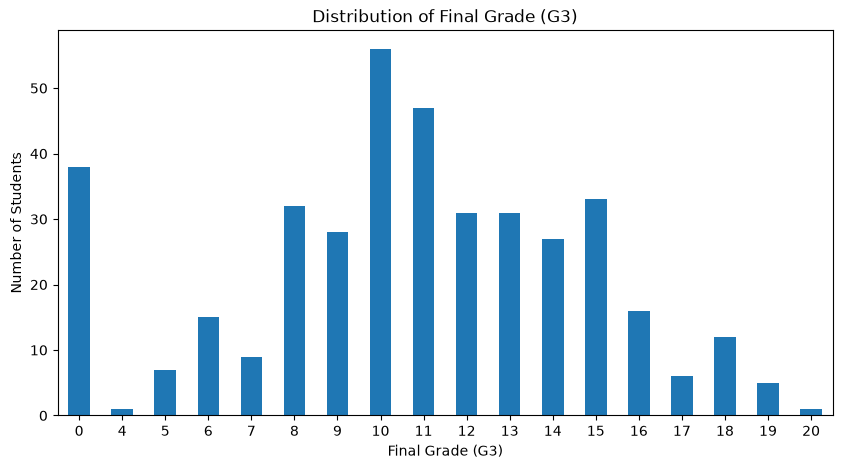

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

df["G3"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

In [6]:
# STEP 3 - Create Classification Target

PASS_THRESHOLD = 10

df["performance"] = np.where(
    df["G3"] >= PASS_THRESHOLD,
    "Pass",
    "Fail"
)

print("Classification rule:")
print("G3 >= 10  -> Pass")
print("G3 < 10   -> Fail")

print("\nClass distribution:")
print(df["performance"].value_counts())

print("\nClass distribution (%):")
print(
    (df["performance"].value_counts(normalize=True) * 100)
    .round(2)
)

Classification rule:
G3 >= 10  -> Pass
G3 < 10   -> Fail

Class distribution:
performance
Pass    265
Fail    130
Name: count, dtype: int64

Class distribution (%):
performance
Pass    67.09
Fail    32.91
Name: proportion, dtype: float64


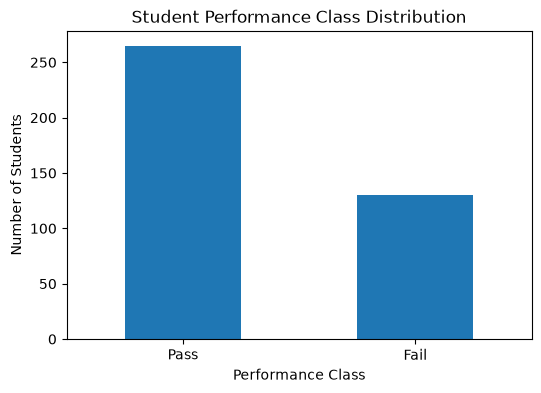

In [7]:
plt.figure(figsize=(6, 4))

df["performance"].value_counts().plot(kind="bar")

plt.title("Student Performance Class Distribution")
plt.xlabel("Performance Class")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.show()

In [8]:
print("Target variable:", "performance")
print("Number of classes:", df["performance"].nunique())
print("Classes:", df["performance"].unique())

Target variable: performance
Number of classes: 2
Classes: <StringArray>
['Fail', 'Pass']
Length: 2, dtype: str


In [9]:
# STEP 4 - Separate Features and Target

# Target variable
y = df["performance"]

# Remove target-related columns from the input features
X = df.drop(columns=["performance", "G3"])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix shape: (395, 32)
Target shape: (395,)

Target distribution:
performance
Pass    265
Fail    130
Name: count, dtype: int64

Feature columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [10]:
print("\nNumerical features:")
print(X.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical features:")
print(X.select_dtypes(exclude=np.number).columns.tolist())


Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [11]:
print("\nNumerical features:")
print(X.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical features:")
print(X.select_dtypes(exclude=np.number).columns.tolist())


Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [12]:
print("Missing values:")
print(X.isnull().sum())

print("\nTotal missing values:", X.isnull().sum().sum())

Missing values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
dtype: int64

Total missing values: 0


In [13]:
print("Duplicate rows:", X.duplicated().sum())

Duplicate rows: 0


In [14]:
# STEP 5 - Train/Test Split

from sklearn.model_selection import train_test_split

print("Original dataset shape:")
print("X:", X.shape)
print("y:", y.shape)

Original dataset shape:
X: (395, 32)
y: (395,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (316, 32)
y_train: (316,)

Testing set:
X_test: (79, 32)
y_test: (79,)


In [16]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class distribution (%):")
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

print("\nTesting class distribution:")
print(y_test.value_counts())

print("\nTesting class distribution (%):")
print(
    (y_test.value_counts(normalize=True) * 100).round(2)
)

Training class distribution:
performance
Pass    212
Fail    104
Name: count, dtype: int64

Training class distribution (%):
performance
Pass    67.09
Fail    32.91
Name: proportion, dtype: float64

Testing class distribution:
performance
Pass    53
Fail    26
Name: count, dtype: int64

Testing class distribution (%):
performance
Pass    67.09
Fail    32.91
Name: proportion, dtype: float64


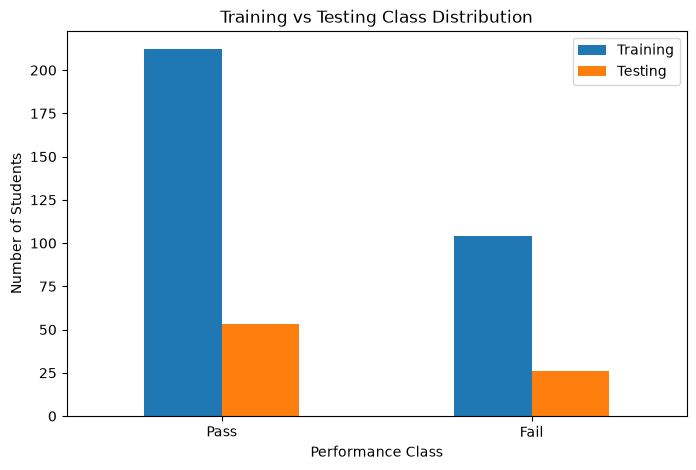

In [17]:
import matplotlib.pyplot as plt

train_counts = y_train.value_counts()
test_counts = y_test.value_counts()

comparison = pd.DataFrame({
    "Training": train_counts,
    "Testing": test_counts
}).fillna(0)

comparison.plot(kind="bar", figsize=(8, 5))

plt.title("Training vs Testing Class Distribution")
plt.xlabel("Performance Class")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [18]:
# Check that training and testing indices do not overlap

overlap = set(X_train.index).intersection(set(X_test.index))

print("Number of overlapping records:", len(overlap))

if len(overlap) == 0:
    print("✓ No overlap between training and testing data.")
else:
    print("⚠️ Overlap detected.")

Number of overlapping records: 0
✓ No overlap between training and testing data.


In [19]:
print("TRAIN/TEST SPLIT DECISION")
print("-" * 40)
print("Training data: 80%")
print("Testing data: 20%")
print("Random state: 42")
print("Stratification: Enabled")
print()
print("Reason:")
print(
    "The dataset is divided into training and testing subsets so that "
    "the models can learn from one portion of the data and be evaluated "
    "on previously unseen records. Stratification is used to preserve "
    "the Pass/Fail class distribution across both subsets."
)

TRAIN/TEST SPLIT DECISION
----------------------------------------
Training data: 80%
Testing data: 20%
Random state: 42
Stratification: Enabled

Reason:
The dataset is divided into training and testing subsets so that the models can learn from one portion of the data and be evaluated on previously unseen records. Stratification is used to preserve the Pass/Fail class distribution across both subsets.


In [20]:
# STEP 6 - Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Preprocessing libraries imported successfully.")

Preprocessing libraries imported successfully.


In [21]:
# Identify feature types

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["int64", "float64"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nNumber of numerical features:", len(numeric_features))

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Number of numerical features: 15

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Number of categorical features: 17


In [22]:
# Numerical preprocessing pipeline

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

print("Numerical pipeline:")
print(numeric_pipeline)

Numerical pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [23]:
# Categorical preprocessing pipeline

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

print("Categorical pipeline:")
print(categorical_pipeline)

Categorical pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])


In [24]:
# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Combined preprocessing pipeline:")
print(preprocessor)

Combined preprocessing pipeline:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'Medu', 'Fedu', 'traveltime',
                                  'studytime', 'failures', 'famrel', 'freetime',
                                  'goout', 'Dalc', 'Walc', 'health', 'absences',
                                  'G1', 'G2']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output

In [25]:
# Fit preprocessing only on training data

X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted preprocessing
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (316, 58)
Processed testing shape: (79, 58)


In [26]:
print(
    "Missing values in processed training data:",
    np.isnan(X_train_processed).sum()
)

print(
    "Missing values in processed testing data:",
    np.isnan(X_test_processed).sum()
)

Missing values in processed training data: 0
Missing values in processed testing data: 0


In [27]:
feature_names = preprocessor.get_feature_names_out()

print("Total processed features:", len(feature_names))

print("\nFirst 30 processed feature names:")
print(feature_names[:30])

Total processed features: 58

First 30 processed feature names:
['num__age' 'num__Medu' 'num__Fedu' 'num__traveltime' 'num__studytime'
 'num__failures' 'num__famrel' 'num__freetime' 'num__goout' 'num__Dalc'
 'num__Walc' 'num__health' 'num__absences' 'num__G1' 'num__G2'
 'cat__school_GP' 'cat__school_MS' 'cat__sex_F' 'cat__sex_M'
 'cat__address_R' 'cat__address_U' 'cat__famsize_GT3' 'cat__famsize_LE3'
 'cat__Pstatus_A' 'cat__Pstatus_T' 'cat__Mjob_at_home' 'cat__Mjob_health'
 'cat__Mjob_other' 'cat__Mjob_services' 'cat__Mjob_teacher']


In [28]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

print("Processed training data:")
display(X_train_processed_df.head())

print("\nProcessed testing data:")
display(X_test_processed_df.head())

Processed training data:


,num__age,num__Medu,num__Fedu,num__traveltime,num__studytime,num__failures,num__famrel,num__freetime,num__goout,num__Dalc,...,cat__activities_no,cat__activities_yes,cat__nursery_no,cat__nursery_yes,cat__higher_no,cat__higher_yes,cat__internet_no,cat__internet_yes,cat__romantic_no,cat__romantic_yes
140,-1.305332,1.135587,0.462701,0.722867,2.386735,-0.442589,-2.091898,-1.272747,-1.038594,-0.554434,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
245,-0.524111,-0.667656,-1.388103,2.115708,-1.262660,-0.442589,0.093357,-0.269784,-0.136957,-0.554434,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
131,-1.305332,-1.569278,-1.388103,2.115708,-1.262660,-0.442589,0.093357,-0.269784,-0.136957,-0.554434,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
153,1.819554,0.233965,-0.462701,-0.669974,-1.262660,3.553358,0.093357,1.736141,0.764679,-0.554434,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
386,1.038332,1.135587,1.388103,2.115708,-1.262660,-0.442589,0.093357,0.733178,-0.136957,0.513866,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0



Processed testing data:


,num__age,num__Medu,num__Fedu,num__traveltime,num__studytime,num__failures,num__famrel,num__freetime,num__goout,num__Dalc,...,cat__activities_no,cat__activities_yes,cat__nursery_no,cat__nursery_yes,cat__higher_no,cat__higher_yes,cat__internet_no,cat__internet_yes,cat__romantic_no,cat__romantic_yes
305,1.038332,-0.667656,1.388103,-0.669974,-0.046195,0.889393,0.093357,0.733178,-0.136957,-0.554434,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
225,1.038332,0.233965,-1.388103,-0.669974,-0.046195,0.889393,1.185985,-0.269784,-0.136957,-0.554434,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
237,-0.524111,-0.667656,-1.388103,-0.669974,-1.262660,-0.442589,0.093357,1.736141,-1.038594,-0.554434,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
318,0.257111,0.233965,1.388103,-0.669974,1.170270,-0.442589,0.093357,-0.269784,0.764679,0.513866,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
182,0.257111,-0.667656,1.388103,-0.669974,-0.046195,-0.442589,1.185985,0.733178,-1.038594,0.513866,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0


In [29]:
preprocessing_decisions = {
    "Numerical missing values": "Median imputation",
    "Categorical missing values": "Most-frequent imputation",
    "Numerical scaling": "StandardScaler",
    "Categorical encoding": "OneHotEncoder",
    "Unknown categories": "Ignored using handle_unknown='ignore'",
    "Data leakage prevention": "Preprocessor fitted only on training data",
    "Target leakage prevention": "G3 excluded from feature matrix"
}

print("PREPROCESSING DECISION LOG")
print("=" * 50)

for decision, method in preprocessing_decisions.items():
    print(f"{decision}: {method}")

PREPROCESSING DECISION LOG
Numerical missing values: Median imputation
Categorical missing values: Most-frequent imputation
Numerical scaling: StandardScaler
Categorical encoding: OneHotEncoder
Unknown categories: Ignored using handle_unknown='ignore'
Data leakage prevention: Preprocessor fitted only on training data
Target leakage prevention: G3 excluded from feature matrix


In [30]:
# STEP 7 - Baseline Model

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Baseline and evaluation libraries imported successfully.")

Baseline and evaluation libraries imported successfully.


In [31]:
# Create baseline model

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(
    X_train_processed,
    y_train
)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [32]:
# Baseline predictions

y_pred_baseline = baseline_model.predict(
    X_test_processed
)

print("First 20 baseline predictions:")
print(y_pred_baseline[:20])

First 20 baseline predictions:
['Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass'
 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass']


In [34]:
# Evaluate baseline

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

baseline_precision = precision_score(
    y_test,
    y_pred_baseline,
    pos_label="Pass",
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline,
    pos_label="Pass",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    pos_label="Pass",
    zero_division=0
)

print("BASELINE PERFORMANCE")
print("=" * 40)
print(f"Accuracy :  {baseline_accuracy:.4f}")
print(f"Precision:  {baseline_precision:.4f}")
print(f"Recall   :  {baseline_recall:.4f}")
print(f"F1-score :  {baseline_f1:.4f}")

BASELINE PERFORMANCE
Accuracy :  0.6709
Precision:  0.6709
Recall   :  1.0000
F1-score :  0.8030


In [35]:
# Detailed baseline classification report

print("Baseline Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_baseline,
        zero_division=0
    )
)

Baseline Classification Report
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00        26
        Pass       0.67      1.00      0.80        53

    accuracy                           0.67        79
   macro avg       0.34      0.50      0.40        79
weighted avg       0.45      0.67      0.54        79



In [36]:
# Baseline confusion matrix

cm_baseline = confusion_matrix(
    y_test,
    y_pred_baseline,
    labels=["Fail", "Pass"]
)

print("Baseline Confusion Matrix:")
print(cm_baseline)

Baseline Confusion Matrix:
[[ 0 26]
 [ 0 53]]


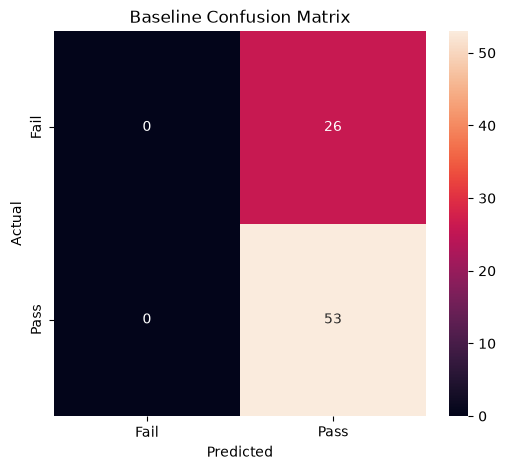

In [37]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
# Store baseline results for later model comparison

results = []

results.append({
    "Model": "Dummy Baseline",
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1-Score": baseline_f1
})

baseline_results_df = pd.DataFrame(results)

display(baseline_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Dummy Baseline,0.670886,0.670886,1.0,0.80303


In [40]:
# STEP 8 - Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [41]:
# Logistic Regression predictions

y_pred_lr = logistic_model.predict(
    X_test_processed
)

print("First 20 predictions:")
print(y_pred_lr[:20])

First 20 predictions:
['Pass' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass'
 'Pass' 'Fail' 'Pass' 'Pass' 'Fail' 'Pass' 'Fail' 'Fail' 'Fail' 'Fail']


In [43]:
print("Logistic Regression Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_lr,
        zero_division=0
    )
)

Logistic Regression Classification Report
              precision    recall  f1-score   support

        Fail       0.75      0.92      0.83        26
        Pass       0.96      0.85      0.90        53

    accuracy                           0.87        79
   macro avg       0.85      0.89      0.86        79
weighted avg       0.89      0.87      0.88        79



In [42]:
# Evaluate Logistic Regression

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    pos_label="Pass",
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    pos_label="Pass",
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    pos_label="Pass",
    zero_division=0
)

print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 45)
print(f"Accuracy :  {lr_accuracy:.4f}")
print(f"Precision:  {lr_precision:.4f}")
print(f"Recall   :  {lr_recall:.4f}")
print(f"F1-score :  {lr_f1:.4f}")

LOGISTIC REGRESSION PERFORMANCE
Accuracy :  0.8734
Precision:  0.9574
Recall   :  0.8491
F1-score :  0.9000


In [44]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=["Fail", "Pass"]
)

print("Logistic Regression Confusion Matrix:")
print(cm_lr)

Logistic Regression Confusion Matrix:
[[24  2]
 [ 8 45]]


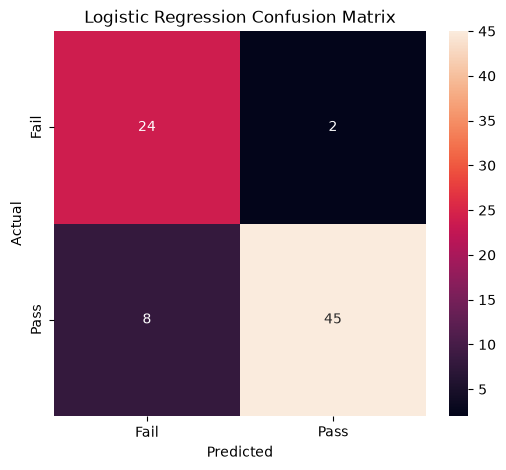

In [45]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1-Score": lr_f1
})

results_df = pd.DataFrame(results)

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Dummy Baseline,0.6709,0.6709,1.0000,0.803
1,Logistic Regression,0.8734,0.9574,0.8491,0.900


In [47]:
results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1-Score": lr_f1
})

results_df = pd.DataFrame(results)

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Dummy Baseline,0.6709,0.6709,1.0000,0.803
1,Logistic Regression,0.8734,0.9574,0.8491,0.900
2,Logistic Regression,0.8734,0.9574,0.8491,0.900


In [48]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest trained successfully.")

NameError: name 'RandomForestClassifier' is not defined

In [49]:
# STEP 9 - Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

print("Random Forest library imported successfully.")

Random Forest library imported successfully.


In [50]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [51]:
# Random Forest predictions

y_pred_rf = rf_model.predict(
    X_test_processed
)

print("First 20 Random Forest predictions:")
print(y_pred_rf[:20])

First 20 Random Forest predictions:
['Pass' 'Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass'
 'Pass' 'Fail' 'Pass' 'Pass' 'Fail' 'Pass' 'Fail' 'Fail' 'Fail' 'Fail']


In [52]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    pos_label="Pass",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    pos_label="Pass",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    pos_label="Pass",
    zero_division=0
)

print("RANDOM FOREST PERFORMANCE")
print("=" * 45)
print(f"Accuracy :  {rf_accuracy:.4f}")
print(f"Precision:  {rf_precision:.4f}")
print(f"Recall   :  {rf_recall:.4f}")
print(f"F1-score :  {rf_f1:.4f}")

RANDOM FOREST PERFORMANCE
Accuracy :  0.8734
Precision:  0.9574
Recall   :  0.8491
F1-score :  0.9000


In [53]:
# Random Forest classification report

print("Random Forest Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

        Fail       0.75      0.92      0.83        26
        Pass       0.96      0.85      0.90        53

    accuracy                           0.87        79
   macro avg       0.85      0.89      0.86        79
weighted avg       0.89      0.87      0.88        79



In [54]:
# Random Forest confusion matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["Fail", "Pass"]
)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[24  2]
 [ 8 45]]


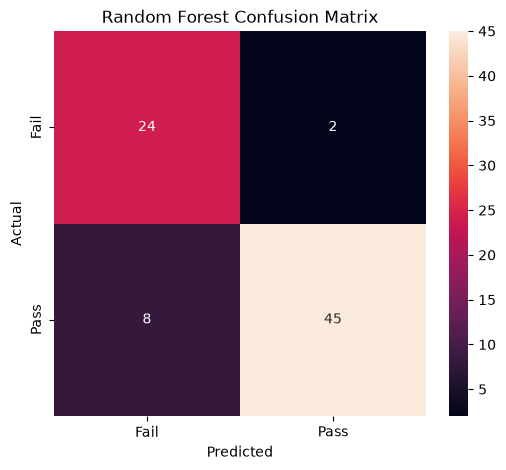

In [55]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:
# Add Random Forest results

results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1
})

results_df = pd.DataFrame(results)

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Dummy Baseline,0.6709,0.6709,1.0000,0.803
1,Logistic Regression,0.8734,0.9574,0.8491,0.900
2,Logistic Regression,0.8734,0.9574,0.8491,0.900
3,Random Forest,0.8734,0.9574,0.8491,0.900


In [57]:
# STEP 10 - Model Comparison

results_df = pd.DataFrame(results)

print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(
    results_df.round(4)
)

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
0,Dummy Baseline,0.6709,0.6709,1.0000,0.803
1,Logistic Regression,0.8734,0.9574,0.8491,0.900
2,Logistic Regression,0.8734,0.9574,0.8491,0.900
3,Random Forest,0.8734,0.9574,0.8491,0.900


In [59]:
# Identify the highest F1-score

best_f1_index = results_df["F1-Score"].idxmax()

print("Model with highest F1-score:")
print(results_df.loc[best_f1_index, "Model"])

print(
    "\nF1-score:",
    round(results_df.loc[best_f1_index, "F1-Score"], 4)
)

Model with highest F1-score:
Logistic Regression

F1-score: 0.9


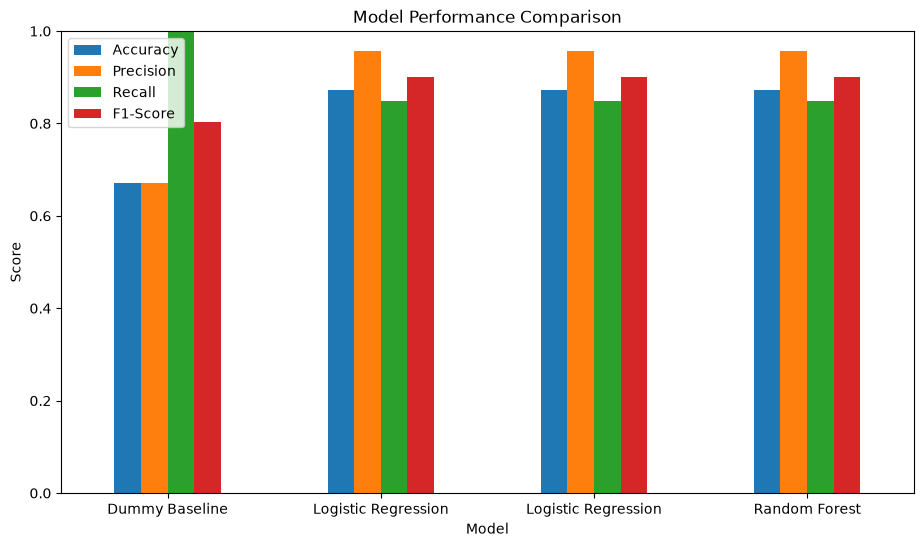

In [60]:
# Compare model metrics visually

results_plot = results_df.set_index("Model")

results_plot[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [61]:
# Save model comparison results

results_df.to_csv(
    "../reports/week3_model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [62]:
# STEP 11 - Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_validate

print("Cross-validation libraries imported successfully.")

Cross-validation libraries imported successfully.


In [63]:
# Create complete ML pipelines

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Logistic Regression pipeline created.")
print("Random Forest pipeline created.")

Logistic Regression pipeline created.
Random Forest pipeline created.


In [64]:
# 5-fold stratified cross-validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print("Number of folds:", cv.n_splits)
print("Stratification: Enabled")
print("Shuffle: Enabled")
print("Random state:", cv.random_state)

Cross-validation strategy:
Number of folds: 5
Stratification: Enabled
Shuffle: Enabled
Random state: 42


In [65]:
# Evaluation metrics

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

print("Evaluation metrics:")
print(list(scoring.keys()))

Evaluation metrics:
['accuracy', 'precision', 'recall', 'f1']


In [67]:
# Evaluation metrics

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

print("Evaluation metrics:")
print(list(scoring.keys()))

Evaluation metrics:
['accuracy', 'precision', 'recall', 'f1']


In [69]:
# STEP 11 - Correct Cross-Validation Scoring

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer

In [70]:
# Define metrics with "Pass" as the positive class

scoring = {
    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        pos_label="Pass",
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        pos_label="Pass",
        zero_division=0
    ),

    "f1": make_scorer(
        f1_score,
        pos_label="Pass",
        zero_division=0
    )
}

print("Scoring configuration:")
print("Positive class:", "Pass")
print("Metrics:", list(scoring.keys()))

Scoring configuration:
Positive class: Pass
Metrics: ['accuracy', 'precision', 'recall', 'f1']


In [71]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross-Validation")
print("Folds:", 5)
print("Shuffle:", True)
print("Random state:", 42)

5-Fold Stratified Cross-Validation
Folds: 5
Shuffle: True
Random state: 42


In [72]:
# Logistic Regression Cross-Validation

lr_cv_results = cross_validate(
    lr_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

print("Logistic Regression cross-validation completed.")

Logistic Regression cross-validation completed.


In [73]:
# Random Forest Cross-Validation

rf_cv_results = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print("Random Forest cross-validation completed.")

Random Forest cross-validation completed.


In [74]:
# Check whether any scoring failed

print("Logistic Regression NaN check:")
for metric in scoring:
    print(
        metric,
        np.isnan(lr_cv_results[f"test_{metric}"]).any()
    )

print("\nRandom Forest NaN check:")
for metric in scoring:
    print(
        metric,
        np.isnan(rf_cv_results[f"test_{metric}"]).any()
    )

Logistic Regression NaN check:
accuracy False
precision False
recall False
f1 False

Random Forest NaN check:
accuracy False
precision False
recall False
f1 False


In [76]:
# Cross-validation summary

cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy Mean": [
        lr_cv_results["test_accuracy"].mean(),
        rf_cv_results["test_accuracy"].mean()
    ],

    "Accuracy Std": [
        lr_cv_results["test_accuracy"].std(),
        rf_cv_results["test_accuracy"].std()
    ],

    "Precision Mean": [
        lr_cv_results["test_precision"].mean(),
        rf_cv_results["test_precision"].mean()
    ],

    "Recall Mean": [
        lr_cv_results["test_recall"].mean(),
        rf_cv_results["test_recall"].mean()
    ],

    "F1 Mean": [
        lr_cv_results["test_f1"].mean(),
        rf_cv_results["test_f1"].mean()
    ],

    "F1 Std": [
        lr_cv_results["test_f1"].std(),
        rf_cv_results["test_f1"].std()
    ]
})

display(cv_comparison.round(4))

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,F1 Std
0,Logistic Regression,0.9215,0.0095,0.9438,0.9396,0.9414,0.0067
1,Random Forest,0.9089,0.0293,0.9410,0.9245,0.9319,0.0202


In [77]:
# F1-score for every fold

fold_f1 = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Logistic Regression": lr_cv_results["test_f1"],
    "Random Forest": rf_cv_results["test_f1"]
})

display(fold_f1.round(4))

,Fold,Logistic Regression,Random Forest
0,1,0.9333,0.9231
1,2,0.9346,0.9623
2,3,0.9434,0.9009
3,4,0.9444,0.9320
4,5,0.9515,0.9412


In [78]:
# Training vs validation F1

overfitting_check = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Training F1 Mean": [
        lr_cv_results["train_f1"].mean(),
        rf_cv_results["train_f1"].mean()
    ],

    "Validation F1 Mean": [
        lr_cv_results["test_f1"].mean(),
        rf_cv_results["test_f1"].mean()
    ]
})

overfitting_check["F1 Gap"] = (
    overfitting_check["Training F1 Mean"]
    - overfitting_check["Validation F1 Mean"]
)

display(overfitting_check.round(4))

,Model,Training F1 Mean,Validation F1 Mean,F1 Gap
0,Logistic Regression,0.9778,0.9414,0.0364
1,Random Forest,1.0000,0.9319,0.0681


In [79]:
display(cv_comparison.round(4))

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,F1 Std
0,Logistic Regression,0.9215,0.0095,0.9438,0.9396,0.9414,0.0067
1,Random Forest,0.9089,0.0293,0.9410,0.9245,0.9319,0.0202


In [80]:
display(overfitting_check.round(4))

,Model,Training F1 Mean,Validation F1 Mean,F1 Gap
0,Logistic Regression,0.9778,0.9414,0.0364
1,Random Forest,1.0000,0.9319,0.0681


In [81]:
# STEP 12 - Hyperparameter Tuning

from sklearn.model_selection import RandomizedSearchCV

print("RandomizedSearchCV imported successfully.")

RandomizedSearchCV imported successfully.


In [82]:
# Logistic Regression hyperparameter search space

lr_param_distributions = {
    "model__C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "model__solver": [
        "liblinear",
        "lbfgs"
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]
}

print("Logistic Regression parameters:")
for parameter, values in lr_param_distributions.items():
    print(parameter, ":", values)

Logistic Regression parameters:
model__C : [0.001, 0.01, 0.1, 1, 10, 100]
model__solver : ['liblinear', 'lbfgs']
model__class_weight : [None, 'balanced']


In [84]:
from sklearn.metrics import make_scorer, f1_score

# F1 scorer with Pass as the positive class
f1_pass_scorer = make_scorer(
    f1_score,
    pos_label="Pass",
    zero_division=0
)

print("Custom F1 scorer created.")
print("Positive class:", "Pass")

Custom F1 scorer created.
Positive class: Pass


In [85]:
# Logistic Regression hyperparameter tuning

lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_param_distributions,
    n_iter=10,
    scoring=f1_pass_scorer,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

lr_search.fit(X, y)

print("Logistic Regression tuning completed.")

Logistic Regression tuning completed.


In [86]:
print("Best Logistic Regression parameters:")
print(lr_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(round(lr_search.best_score_, 4))

Best Logistic Regression parameters:
{'model__solver': 'lbfgs', 'model__class_weight': None, 'model__C': 1}

Best Cross-Validation F1-score:
0.9414


In [88]:
# STEP 13 - Random Forest Hyperparameter Search Space

rf_param_distributions = {
    "model__n_estimators": [
        100,
        200,
        300,
        500
    ],

    "model__max_depth": [
        None,
        5,
        10,
        15,
        20
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__max_features": [
        "sqrt",
        "log2"
    ],

    "model__class_weight": [
        None,
        "balanced"
    ]
}

print("Random Forest parameter search space created.")

for parameter, values in rf_param_distributions.items():
    print(f"{parameter}: {values}")

Random Forest parameter search space created.
model__n_estimators: [100, 200, 300, 500]
model__max_depth: [None, 5, 10, 15, 20]
model__min_samples_split: [2, 5, 10]
model__min_samples_leaf: [1, 2, 4]
model__max_features: ['sqrt', 'log2']
model__class_weight: [None, 'balanced']


In [89]:
# Random Forest hyperparameter tuning

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=20,
    scoring=f1_pass_scorer,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

rf_search.fit(X, y)

print("Random Forest tuning completed.")

Random Forest tuning completed.


In [90]:
print("BEST RANDOM FOREST PARAMETERS")
print("=" * 50)

print(rf_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(round(rf_search.best_score_, 4))

BEST RANDOM FOREST PARAMETERS
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': None}

Best Cross-Validation F1-score:
0.9376


In [91]:
# Check Random Forest tuning results

rf_nan_count = np.isnan(
    rf_search.cv_results_["mean_test_score"]
).sum()

print("Number of NaN test scores:", rf_nan_count)

if rf_nan_count == 0:
    print("✓ All Random Forest tuning scores are valid.")
else:
    print("⚠️ Some Random Forest scores are NaN.")

Number of NaN test scores: 0
✓ All Random Forest tuning scores are valid.


In [92]:
# Random Forest tuning results

rf_tuning_results = pd.DataFrame(
    rf_search.cv_results_
)

rf_tuning_results = rf_tuning_results[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "rank_test_score"
    ]
].sort_values(
    by="rank_test_score"
)

display(
    rf_tuning_results.head(10).round(4)
)

,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
7,"{'model__n_estimators': 200, 'model__min_sampl...",0.9376,0.0172,1.0000,1
8,"{'model__n_estimators': 100, 'model__min_sampl...",0.9355,0.0269,0.9991,2
9,"{'model__n_estimators': 300, 'model__min_sampl...",0.9340,0.0181,0.9548,3
13,"{'model__n_estimators': 200, 'model__min_sampl...",0.9322,0.0260,0.9656,4
16,"{'model__n_estimators': 300, 'model__min_sampl...",0.9299,0.0254,0.9765,5
1,"{'model__n_estimators': 300, 'model__min_sampl...",0.9297,0.0183,1.0000,6
12,"{'model__n_estimators': 500, 'model__min_sampl...",0.9292,0.0206,1.0000,7
18,"{'model__n_estimators': 500, 'model__min_sampl...",0.9289,0.0231,0.9986,8
11,"{'model__n_estimators': 100, 'model__min_sampl...",0.9284,0.0187,0.9543,9
4,"{'model__n_estimators': 200, 'model__min_sampl...",0.9263,0.0188,0.9538,10


In [93]:
# Evaluate tuned Logistic Regression

best_lr_model = lr_search.best_estimator_

y_pred_tuned_lr = best_lr_model.predict(X_test)

tuned_lr_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_lr
)

tuned_lr_precision = precision_score(
    y_test,
    y_pred_tuned_lr,
    pos_label="Pass",
    zero_division=0
)

tuned_lr_recall = recall_score(
    y_test,
    y_pred_tuned_lr,
    pos_label="Pass",
    zero_division=0
)

tuned_lr_f1 = f1_score(
    y_test,
    y_pred_tuned_lr,
    pos_label="Pass",
    zero_division=0
)

print("TUNED LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy :  {tuned_lr_accuracy:.4f}")
print(f"Precision:  {tuned_lr_precision:.4f}")
print(f"Recall   :  {tuned_lr_recall:.4f}")
print(f"F1-score :  {tuned_lr_f1:.4f}")

TUNED LOGISTIC REGRESSION
Accuracy :  0.9620
Precision:  0.9808
Recall   :  0.9623
F1-score :  0.9714


In [94]:
# Evaluate tuned Random Forest

best_rf_model = rf_search.best_estimator_

y_pred_tuned_rf = best_rf_model.predict(X_test)

tuned_rf_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_rf
)

tuned_rf_precision = precision_score(
    y_test,
    y_pred_tuned_rf,
    pos_label="Pass",
    zero_division=0
)

tuned_rf_recall = recall_score(
    y_test,
    y_pred_tuned_rf,
    pos_label="Pass",
    zero_division=0
)

tuned_rf_f1 = f1_score(
    y_test,
    y_pred_tuned_rf,
    pos_label="Pass",
    zero_division=0
)

print("TUNED RANDOM FOREST")
print("=" * 50)
print(f"Accuracy :  {tuned_rf_accuracy:.4f}")
print(f"Precision:  {tuned_rf_precision:.4f}")
print(f"Recall   :  {tuned_rf_recall:.4f}")
print(f"F1-score :  {tuned_rf_f1:.4f}")

TUNED RANDOM FOREST
Accuracy :  1.0000
Precision:  1.0000
Recall   :  1.0000
F1-score :  1.0000
